In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show_comparision(original,sobel,prewitt,canny):
  plt.figure(figsize=(12,10))
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original')

  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title('Sobel edge detection')
  plt.axis('off')

  plt.subplot(2,2,3)
  plt.imshow(prewitt,cmap='gray')
  plt.title('Prewitt edge detection')
  plt.axis('off')

  plt.subplot(2,2,4)
  plt.imshow(canny,cmap='gray')
  plt.title('Canny edge detection')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

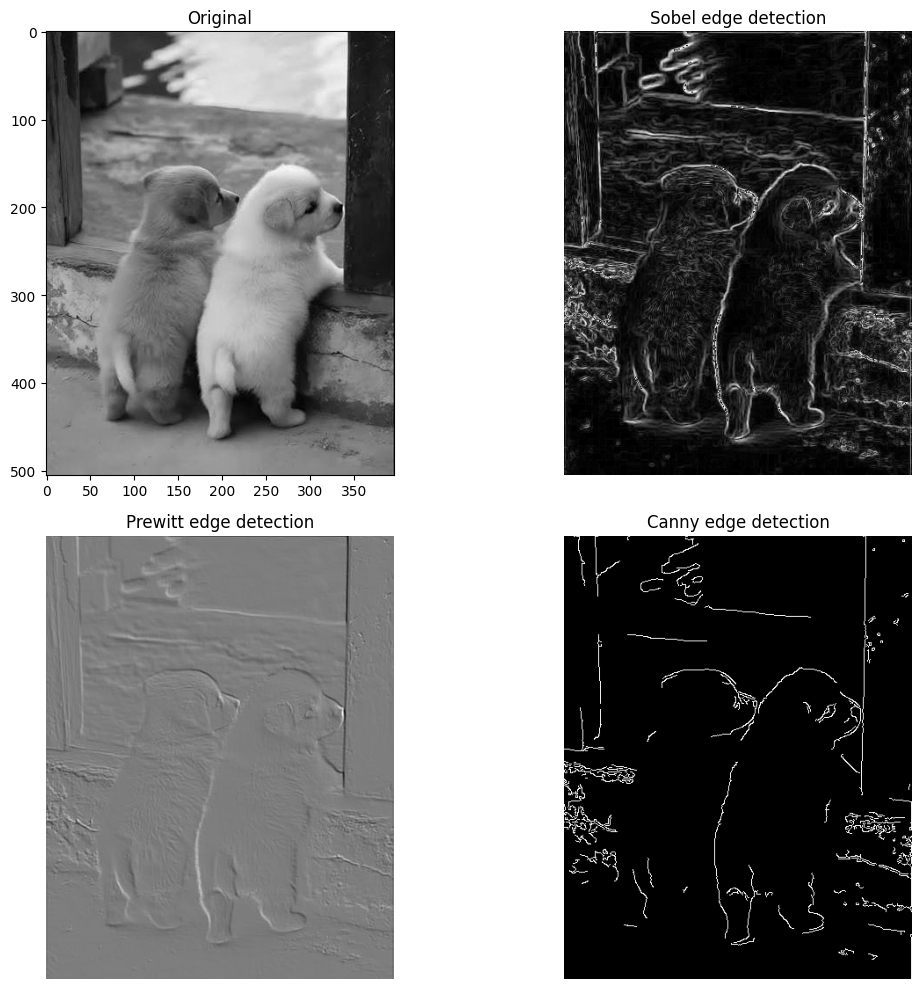

In [4]:
img=cv2.imread('/content/cat.jpg',0)

if img is None:
  print("error:image not found")
else:
  sobelx=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
  sobely=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)

  sobel_combined=cv2.magnitude(sobelx,sobely)

  kernelx=np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
  kernely=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

  prewitty=cv2.filter2D(img,cv2.CV_64F,kernely)
  prewittx=cv2.filter2D(img,cv2.CV_64F,kernelx)
  prewitt_combined=prewittx+prewitty

  canny_edges=cv2.Canny(img,100,200)

  show_comparision(img,np.uint8(np.absolute(sobel_combined)),prewitt_combined,canny_edges)